In [1]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
tqdm.pandas()
#
import matplotlib.pyplot as plt
import matplotlib as mpl
from adjustText import adjust_text
import seaborn as sns
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

#### Load data

In [2]:
# Load in data
data_frame2seq = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/data/conf-bias-output/5KPE-5KPH/designs_conf-bias_frame2seq.csv',
    index_col=0
)
data_proteinmpnn = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/data/conf-bias-output/5KPE-5KPH/designs_conf-bias_proteinmpnn.csv',
    index_col=0
)
data_caliby = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/data/conf-bias-output/5KPE-5KPH/designs_conf-bias_caliby.csv',
    index_col=0
)
data = pd.merge(
    data_frame2seq, data_proteinmpnn,
    on=['name', 'mut'],
    how='left',
    validate='one_to_one'
)
data = pd.merge(
    data, data_caliby,
    on=['name', 'mut'],
    how='left',
    validate='one_to_one'
)

# Separate parameters and sample naming
data['parameters'] = data['name'].apply(
    lambda name : name.split('_5KP')[0], # param
)
data['name'] = data['name'].apply(
    lambda name: f'5KP{name.split("_5KP")[1]}'# name
)

In [3]:
designs = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs/designs.csv')
designs = designs[['parameters', 'id']].reset_index(names='design')
data = data.merge(
    designs,
    how='left',
    left_on=[
        'parameters', 'name'
    ],
    right_on=[
        'parameters',
        'id'
    ],
    validate='many_to_one'
).drop(columns='id')

#### Prepare data

In [38]:
# filter for data of interest
structure = '5KPE'
rmsd = 4
#
graph_df = data[
    #(data['name'].str.contains(f'{structure}_{rmsd}'))
    (~(data['mut'] == 'wt'))
]

In [39]:
# z-score
def z_score(
    df: pd.DataFrame,
    state_cols: list[str],
    flip = False
):
    for col in state_cols:
        df[f'{col}_z'] = (df[col] - df[col].mean()) / df[col].std()
        if flip:
            df[f'{col}_z'] *= -1
    return df

# bias
def bias(
    df: pd.DataFrame,
    state_cols: list[str]
):
    assert len(state_cols) == 2
    #
    for idx in range(2):
        df[f'{state_cols[idx]}_bias'] = (
            df[state_cols[idx]] - df[state_cols[1 - idx]]
        )

    return df

models = ['frame2seq', 'proteinmpnn', 'caliby']
for model in models:
    # normalize
    graph_df = z_score(
        graph_df,
        [f'{model}_pdb0', f'{model}_pdb1'],
        model == 'caliby'
    )

    # transformed -> bias
    graph_df = bias(
        graph_df,
        [f'{model}_pdb0_z', f'{model}_pdb1_z'],
    )

    # untransformed -> bias
    graph_df = bias(
        graph_df,
        [f'{model}_pdb0', f'{model}_pdb1'],
    )

# combine bias
graph_df['combined_bias'] = graph_df[['frame2seq_pdb0_z_bias', 'proteinmpnn_pdb0_z_bias', 'caliby_pdb0_z_bias']].mean(axis=1)


In [42]:
struc = 0
graph_df[
    (graph_df['design'] == 42)
    & (graph_df['mut'].isin([
        'A9L'
    ]))
][[
    'mut',
    # f'proteinmpnn_pdb{struc}_z_bias',
    # f'caliby_pdb{struc}_z_bias',
    # f'frame2seq_pdb{struc}_z_bias',
    'combined_bias'
]]

,mut,combined_bias
57660,A9L,3.882426


#### Plot

Plotting ...


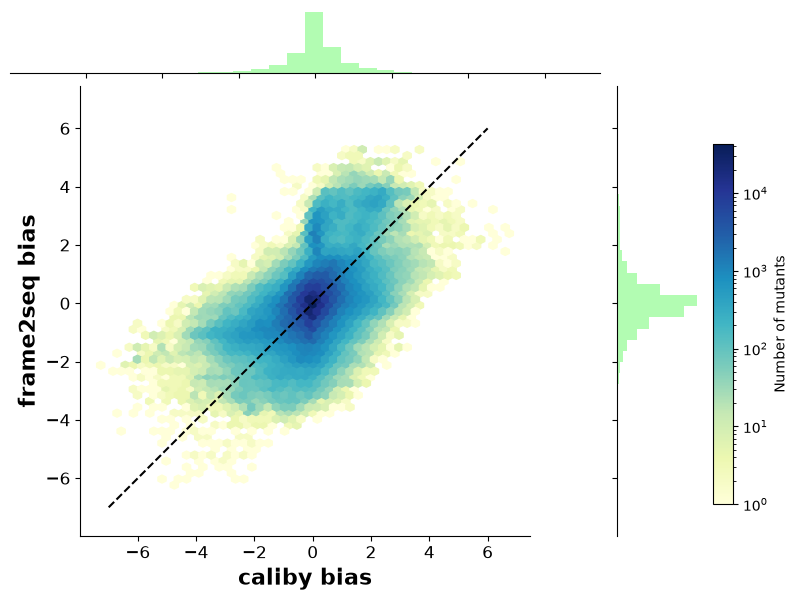

In [30]:
# compare scores
x = 'caliby_pdb0_z_bias'
y = 'frame2seq_pdb0_z_bias'

# sort by combined (summed) bias ~= agreement
graph_df['combined_bias'] = graph_df[x] + graph_df[y]
graph_df = graph_df.sort_values(
    by='combined_bias', ascending=False
).reset_index(drop=True)

# assign bias
# if 'bias' not in graph_df.columns:
#     model = 'proteinmpnn' # with proteinmpnn scores, for now
#     graph_df['bias'] = graph_df.progress_apply(
#         # use proteinmpnn to filter out low expresssion mutants, for now
#         lambda row: assign_bias(row, len(graph_df), 'proteinmpnn'), axis=1
#     ) #type: ignore
#     graph_df['bias'] = graph_df['bias'].astype('category')

# plot
print('Plotting ...')

graph = sns.JointGrid(
    data=graph_df,
    x = x,
    y = y,
    height=6,
    ratio=6
)

# hexbin instead of scatter
hb = graph.ax_joint.hexbin(
    graph_df[x],
    graph_df[y],
    gridsize=50,
    mincnt=1,
    cmap='YlGnBu',
    bins='log'
)

# marginal distributions
sns.histplot(
    data=graph_df,
    x=x,
    ax=graph.ax_marg_x,
    bins=30,
    color='palegreen',
    linewidth=0
)
sns.histplot(
    data=graph_df,
    y=y,
    ax=graph.ax_marg_y,
    bins=30,
    color='palegreen',
    linewidth=0
)

# plot y = x
graph.ax_joint.plot(
    np.arange(-7, 7),
    np.arange(-7, 7),
    color = 'black',
    linestyle='--',
    label='y=x'
)

# axes
ax = graph.ax_joint
ax.set_xlabel(f'{x.split('_')[0]} bias', fontsize=16, fontweight='bold')
ax.set_ylabel(f'{y.split('_')[0]} bias', fontsize=16, fontweight='bold')
ax.tick_params(
    axis='both',
    labelsize=12,
)

# set square axes
ax.set_xlim(
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[-1], ax.get_ylim()[-1])
)
ax.set_ylim(ax.get_xlim())
ax.set_aspect('equal')

# colorbar
graph.figure.set_size_inches(8, 6)
cax = graph.figure.add_axes([
    0.99, 0.15, 0.025, 0.6
]) #type: ignore
cbar = graph.figure.colorbar(
    hb,
    cax=cax
) 
cbar.set_label('Number of mutants')

#
plt.show()

In [38]:
# separate by structure
designs = np.unique(graph_df['design'])
#designs = [0, 20, 233, 417]

graph_dfs = [
    graph_df[graph_df['design'] == design]
    for design in designs
]

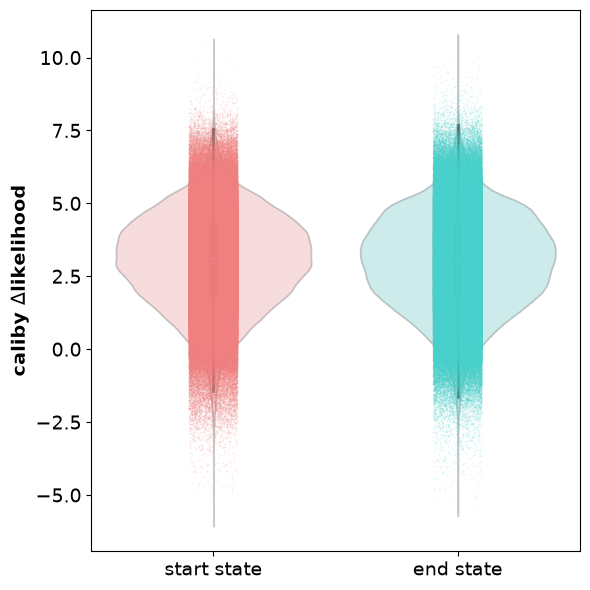

In [32]:
# distributions of raw scores for each state
fig, ax = plt.subplots(figsize=(6, 6))

model = 'caliby'
graph_df_safe = graph_df.copy()
# graph_df = graph_df[
#     (graph_df[f'{model}_pdb1_z'] > 0) | 
#     (graph_df[f'{model}_pdb0_z'] > 0)
# ]

# plot 
sns.violinplot(
    data=graph_df[[
        f'{model}_pdb1',
        f'{model}_pdb0'
    ]],
    palette=[
        'lightcoral',
        'mediumturquoise'
    ],
    alpha = 0.3,
    zorder = -1
)
#
sns.stripplot(
    data=graph_df[[
        f'{model}_pdb1',
        f'{model}_pdb0'
    ]],
    palette=[
        'lightcoral',
        'mediumturquoise'
    ],
    size = 1,
    alpha = 0.2,
    ax=ax
)

# axes
ax.set_xticks([0, 1])
ax.set_xticklabels([
    'start state',
    'end state'
])
ax.set_xlabel(f'', fontsize=16, fontweight='bold')
ax.set_ylabel(rf'{model} $\Delta$likelihood', fontsize=14, fontweight='bold')
ax.tick_params(
    axis='both',
    labelsize=14,
)
plt.tight_layout()
plt.show()

graph_df = graph_df_safe.copy()

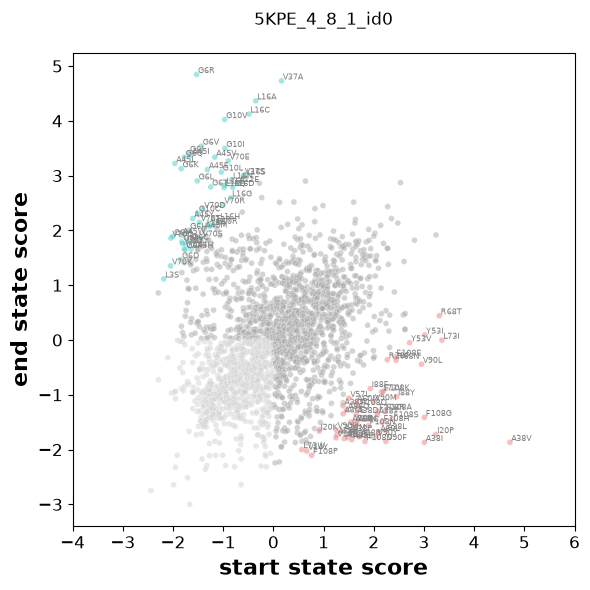

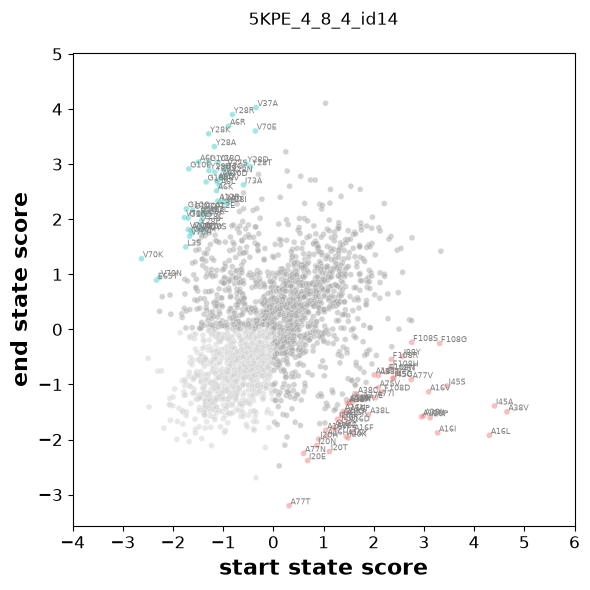

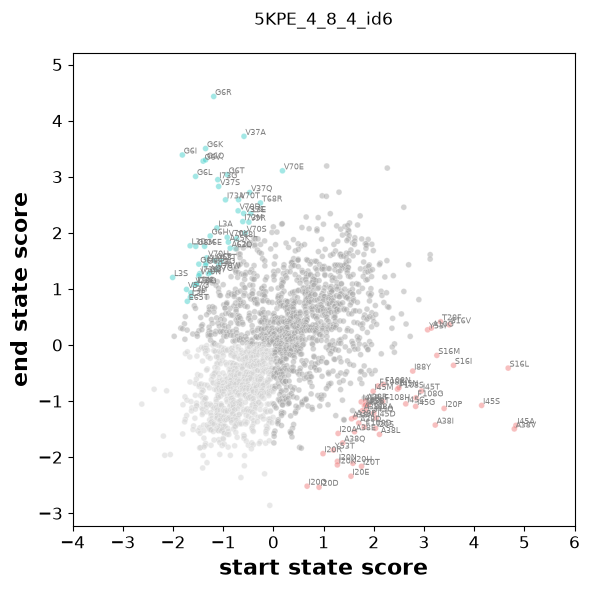

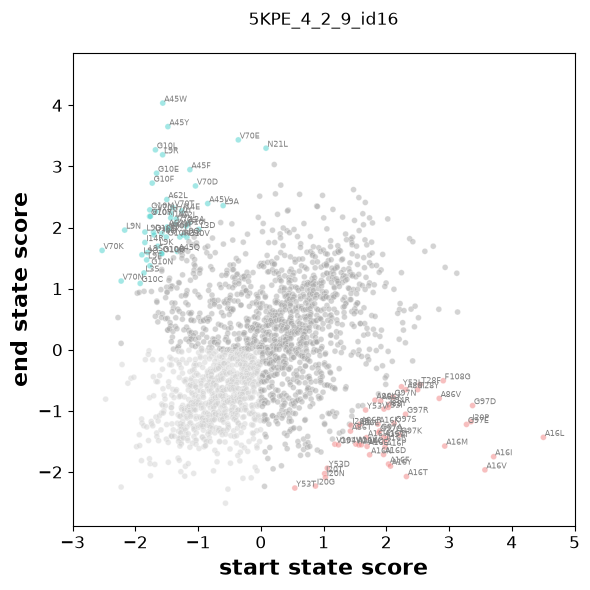

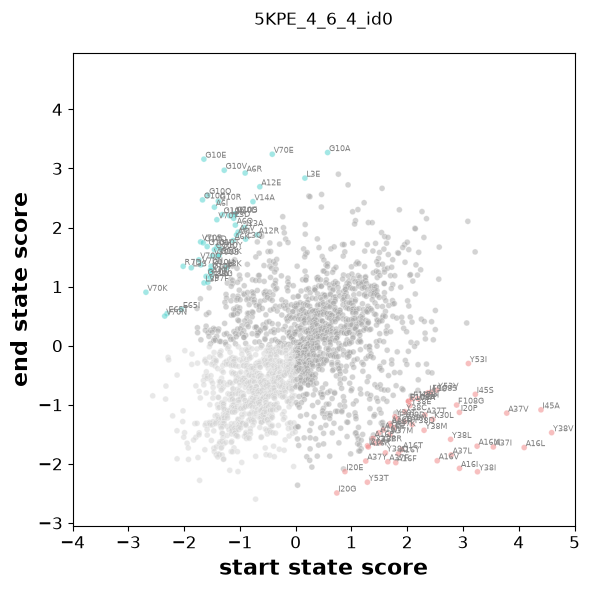

In [39]:
# plot bias for each state (transformed)
def assign_bias(row, total, model):
    # for bias assignment
    frac_mutants = 0.05
    n_biased = round((frac_mutants / 2) * total)

    # get scores
    end = row[f'{model}_pdb0_z']
    start = row[f'{model}_pdb1_z']

    # low := z-score < 0 for both
    if (end < 0 and start < 0):
        return 'low'
    else:
        # end bias
        if row.name < n_biased:
            return 'end'
        # neutral
        elif row.name < (total - n_biased):
            return 'neutral'
        # start bias
        else:
            return 'start'

for df in graph_dfs:
    # sort by bias to end state
    df = df.sort_values(
        f'{model}_pdb0_z_bias', ascending=False
    ).reset_index(drop=True) #biases are symmetrical, can sort with either

    # designate assignments
    if 'bias' not in df.columns:
        df['bias'] = df.apply(
            lambda row: assign_bias(row, len(df), model), axis=1
        )
        df['bias'] = df['bias'].astype('category')

    # figure
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=df,
        x = f'{model}_pdb1_z',
        y = f'{model}_pdb0_z',
        hue = 'bias',
        size = 1,
        alpha = 0.5,
        ax = ax,
        palette = {
            'low': 'lightgray',
            'neutral': 'darkgray',
            'start': 'lightcoral',
            'end': 'mediumturquoise'
        },
        legend=False
    )

    # annotate biased mutants
    for _, row in df[df['bias'].isin(['start', 'end'])].iterrows():
        ax.annotate(
            row['mut'],
            (row[f'{model}_pdb1_z'], row[f'{model}_pdb0_z']),
            xytext=(1, 1),
            textcoords='offset points',
            size='xx-small',
            color='grey'
        )
    
    # axes
    ax.set_xlabel('start state score', fontsize=16, fontweight='bold')
    ax.set_ylabel('end state score', fontsize=16, fontweight='bold')
    ax.tick_params(
        axis='both',
        labelsize=12,
    )
    ax.set_xlim(
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[-1], ax.get_ylim()[-1])
    )
    ax.set_ylim(ax.get_xlim())
    ax.set_xticks(ax.get_yticks())
    ax.set_title(f'{df.loc[0, 'name']}\n')
    plt.tight_layout()
    plt.show()

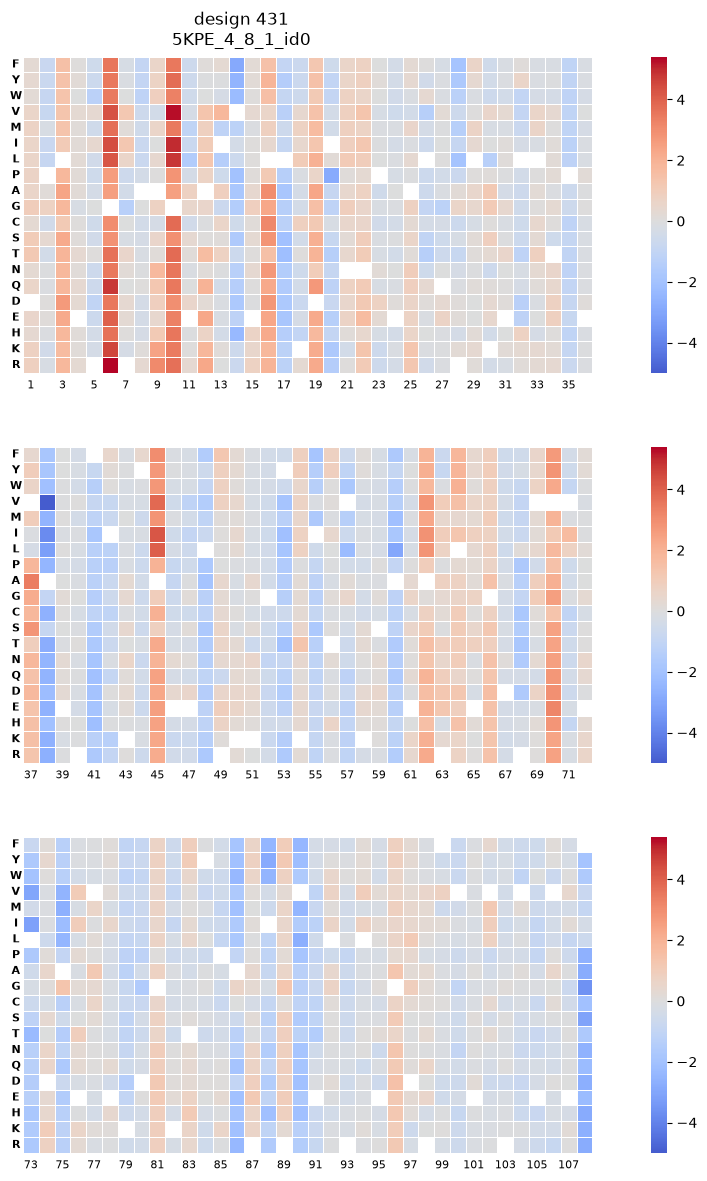

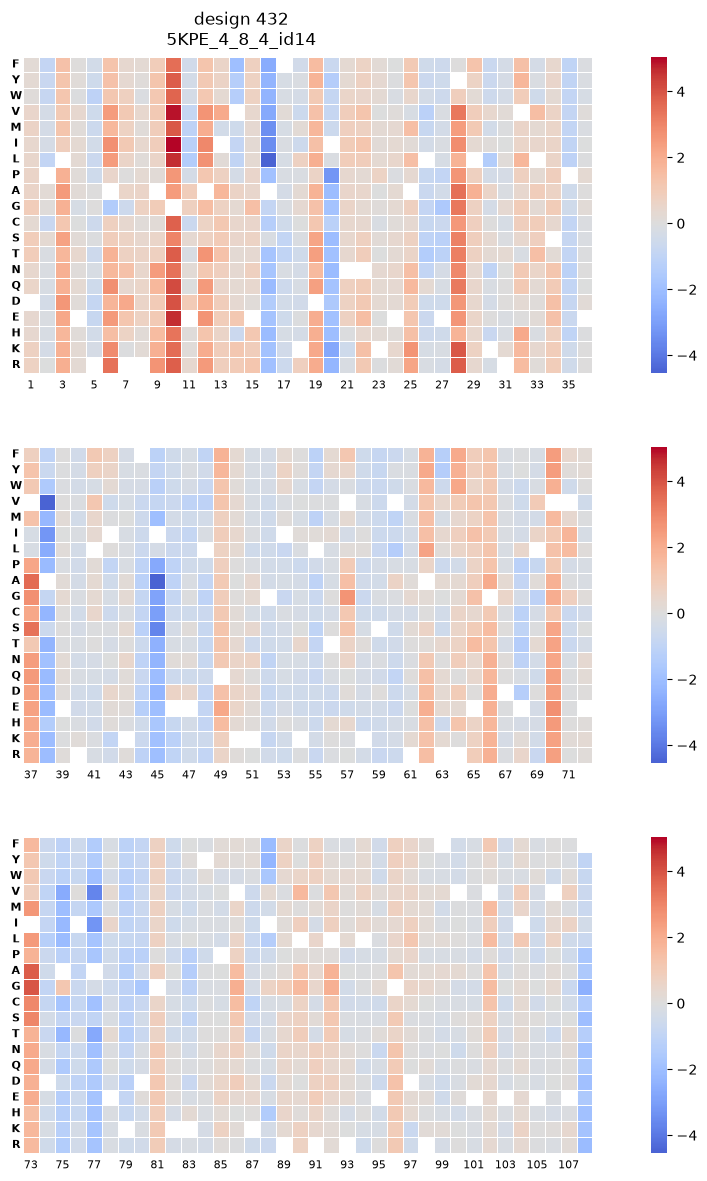

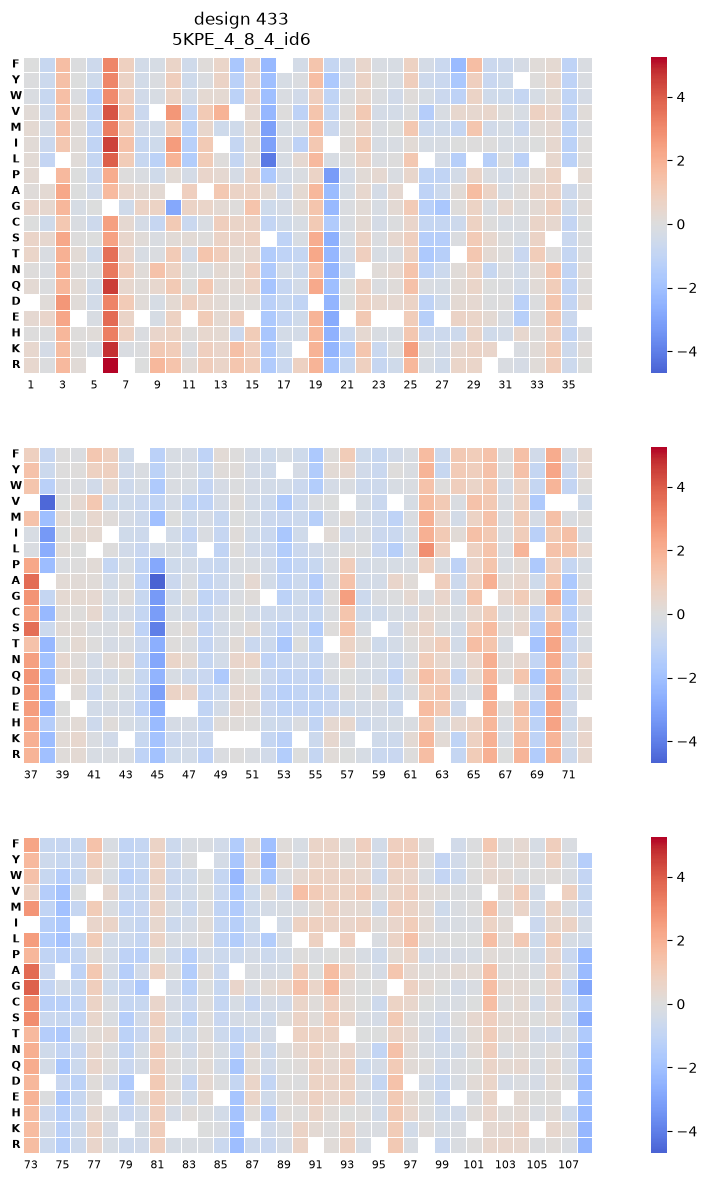

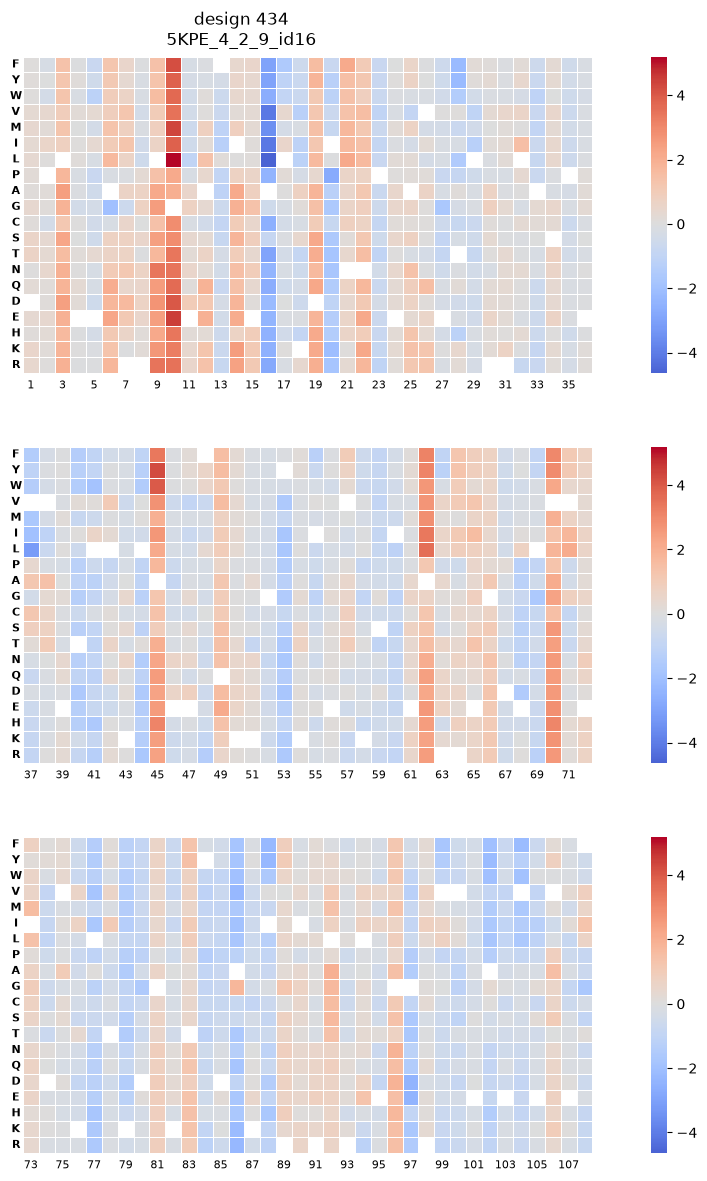

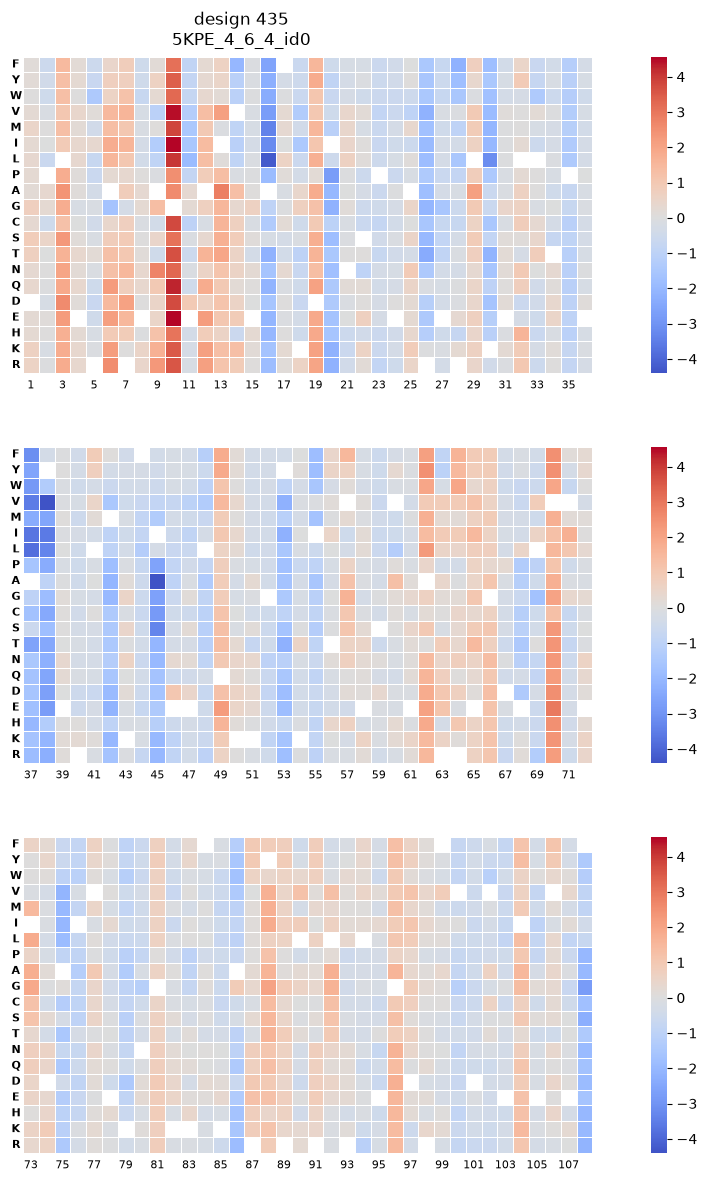

In [41]:
# see all mutants
for df in graph_dfs:
    # get mut idx (x-axis) and mutated to (y-axis) 
    df['mut_idx'] = df['mut'].apply(lambda mut: int(mut[1:-1]))
    df['mut_new'] = df['mut'].apply(lambda mut: mut[-1])

    # pivot df
    heatmap = df.pivot(
        index = 'mut_new', #y-axis
        columns = 'mut_idx', #x-axis
        values = 'combined_bias' #color
    )

    # sort columns in sequence order
    seq_order = np.argsort([int(idx) for idx in heatmap.columns])
    heatmap = heatmap.iloc[:, seq_order]

    # sort rows by AA character
    aa_order = list('FYWVMILPAGCSTNQDEHKR') #by chem character
    heatmap = heatmap.loc[aa_order]

    # split df
    split_num = 3
    mid = int(np.ceil(heatmap.shape[1] / split_num))
    heatmaps = [
        heatmap.iloc[:, (i * mid): ((i + 1) * mid)]
        for i in range(split_num)
    ]

    # same color map for all
    cmap = 'coolwarm'
    vmin = heatmap.min().min()
    vmax = heatmap.max().max()
    center = 0

    # plot
    fig, axes = plt.subplots(
        split_num, 1,
        figsize=(4*split_num, 4*split_num)
    )
    for i in range(split_num):

        ax = axes[i]
        # heatmap
        sns.heatmap(
            heatmaps[i],
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            center=center,
            yticklabels=aa_order,
            xticklabels=[
                str(num) if (num%2==1) else ''
                for num in range(heatmaps[i].columns[0], heatmaps[i].columns[-1] + 1)
            ],
            square=True,
            linewidths=0.5,
            linecolor='white',
            cmap=cmap
        )

        # axes
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.tick_params(
            axis='both',
            labelsize=8,
            labelrotation=0, # turn correct way
            length=0, #ticks off
            pad=5,
        )
        plt.setp(
            ax.get_yticklabels(),
            ha='center',
            fontweight='bold'
        )

        # title
        plt.suptitle(
            f'design {df.iloc[0]['design']}\n{df.iloc[0]['name']}'
        )

    plt.tight_layout(h_pad=4.0)
    plt.show()

##### non-normalized

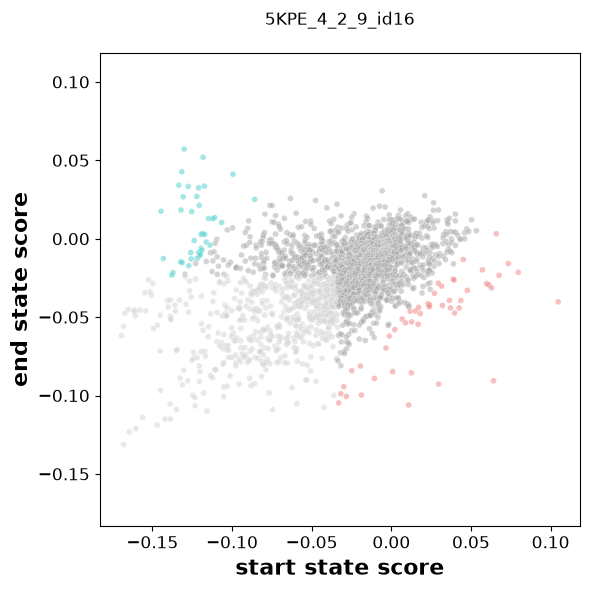

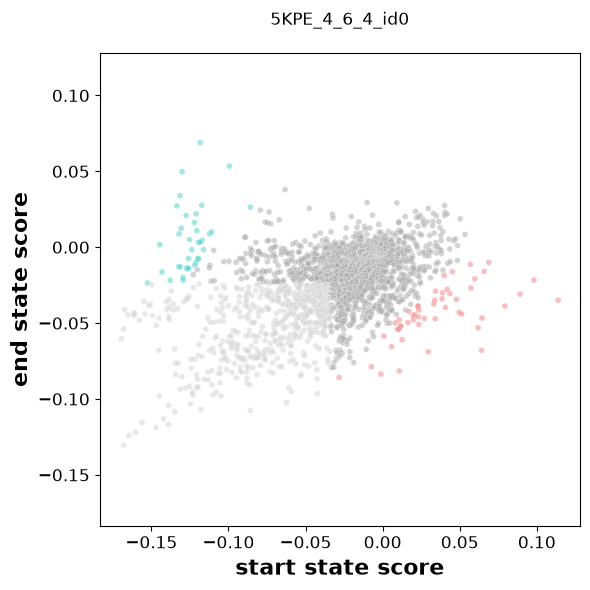

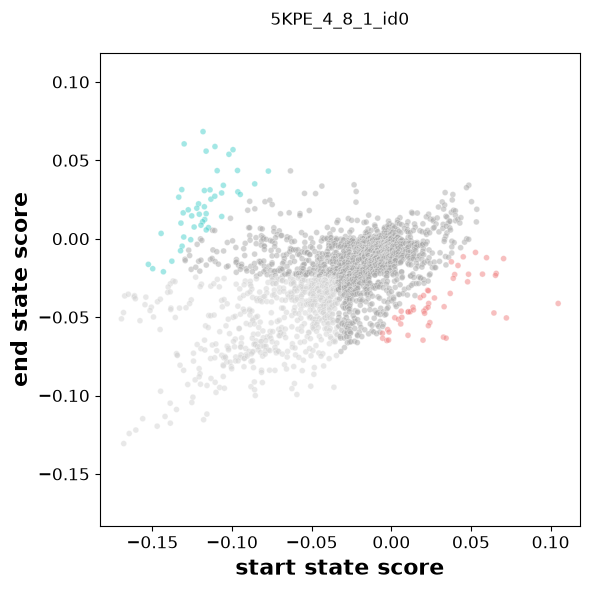

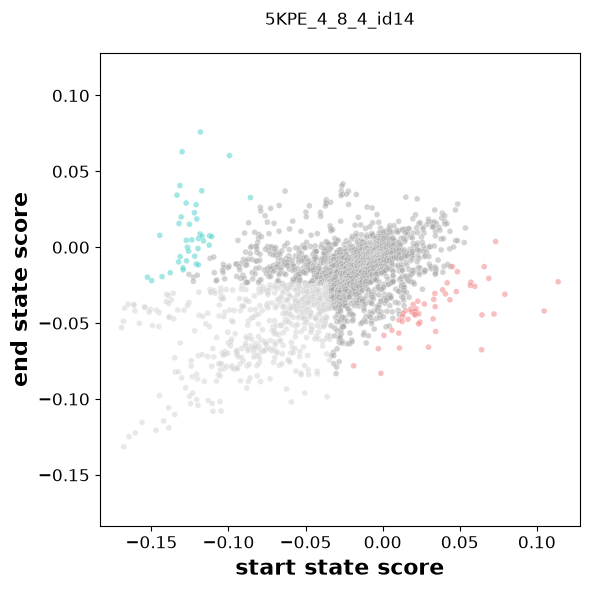

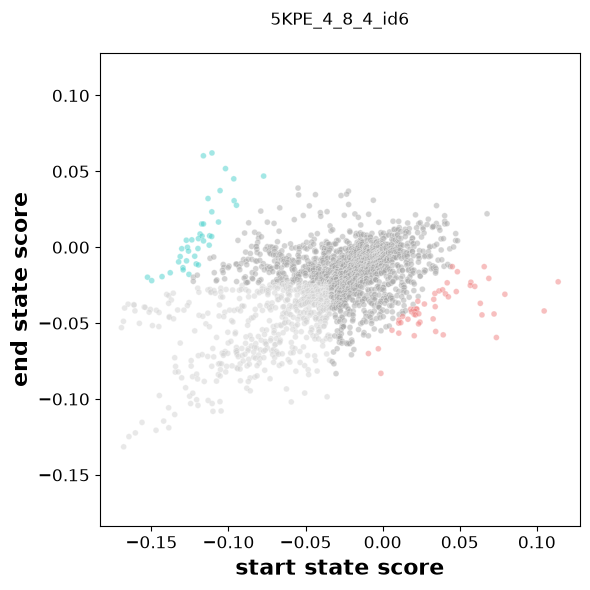

In [ ]:
# plot bias for each state (untransformed)
for df in graph_dfs:
    # sort by bias to end state
    df = df.sort_values(
        f'{model}_pdb0_bias', ascending=False
    ).reset_index(drop=True) #biases are symmetrical, can sort with either

    # designate assignments
    if 'bias' not in df.columns:
        df['bias'] = df.apply(
            lambda row: assign_bias(row, len(df)), axis=1
        )
        df['bias'] = df['bias'].astype('category')

    # figure
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=df,
        x = f'{model}_pdb1',
        y = f'{model}_pdb0',
        hue = 'bias',
        size = 1,
        alpha = 0.5,
        ax = ax,
        palette = {
            'low': 'lightgray',
            'neutral': 'darkgray',
            'start': 'lightcoral',
            'end': 'mediumturquoise'
        },
        legend=False
    )

    for _, row in df[df['bias'].isin(['start', 'end'])].iterrows():
        ax.annotate(
            row['mut'],
            (row[f'{model}_pdb1_z'], row[f'{model}_pdb0_z']),
            xytext=(1, 1),
            textcoords='offset points',
            size='xx-small',
            color='grey'
        )
    
    # axes
    ax.set_xlabel('start state score', fontsize=16, fontweight='bold')
    ax.set_ylabel('end state score', fontsize=16, fontweight='bold')
    ax.tick_params(
        axis='both',
        labelsize=12,
    )
    ax.set_ylim(ax.get_xlim())
    #ax.set_xticks(ax.get_yticks())
    ax.set_title(f'{df.loc[0, 'name']}\n')
    plt.tight_layout()
    plt.show()

#### Top mutants

In [97]:
# top ranked mutants -> start state
df = graph_df
df = df.sort_values(by=f'combined_bias')
num = 100
#
start = df.head(num)
start_names = np.unique(start['design'])
#
end = df.tail(num)
end_names = np.unique(end['design'])
#
names = set(start_names) & set(end_names)

In [118]:
# get 2A designs, top 5 mutants
save_df_list = []
for name in names:
    name_df = df[df['design'] == name]
    name_df = name_df.sort_values(by='combined_bias')
    #
    start = name_df.head(5)
    start['bias'] = 'start'
    save_df_list.append(
        start
    )
    #
    end = name_df.tail(5)
    end['bias'] = 'end'
    save_df_list.append(
        end
    )

save_df = pd.concat(save_df_list)

In [133]:
# get 4A designs, top 10 mutants
save_df_list = []

# all the 4A designs
for design in np.unique(
    data[
        data['name'].apply(
            lambda name: (
                ('5KPE_4_' in name) or
                ('5KPH_4_' in name)
            )
        )
    ]['design']
):
    name_df = graph_df[graph_df['design'] == design]
    name_df = name_df.sort_values(by='combined_bias')
    #
    start = name_df.head(10)
    start['bias'] = 'start'
    save_df_list.append(
        start
    )
    #
    end = name_df.tail(10)
    end['bias'] = 'end'
    save_df_list.append(
        end
    )

save_df = pd.concat(save_df_list)

In [135]:
# get sequence and save for AF input
design_df = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs/designs.csv', index_col=0)
af_input = {
    'id': [],
    'seq': []
}

for idx, row in save_df.iterrows(): #type: ignore
    # name
    af_input['id'].append(
        f'design-{row['design']}_mut-{row['mut']}_bias-{row['bias']}'
    )

    # original seq
    seq = design_df.iloc[row['design']]['sequence'] #type: ignore

    # mutate
    mut = row['mut']
    mut_o = mut[0]
    mut_idx = int(mut[1:-1])
    mut_n = mut[-1]
    seq = seq[:mut_idx - 1] + mut_n + seq[mut_idx:]

    # save
    af_input['seq'].append(seq)

# create df and save
af_input = pd.DataFrame(af_input)
af_input.to_csv(
    '/wynton/home/rotation/geanhu/multi-state/notebooks/data/mutants/5KPE-5KPH_4a.csv',
    index=False
)

#### Check with AF

In [53]:
base_path = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_mutants/4a'

In [54]:
scores = pd.read_csv(
    f'{base_path}/scores.csv', index_col=0
).sort_values(by=['name', 'model'])
scores['design'] = scores['name'].apply(
    lambda name: int(name.split('_')[0].split('-')[1])
)
scores['bias'] = scores['name'].apply(
    lambda name: name.split('bias-')[1]
)

In [55]:
# get backbone info
designs = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs/designs.csv',
    index_col=0
)
designs.set_index('index')
scores['backbone'] = scores['design'].apply(
    lambda design: designs.loc[design]['id'][:10]
)
scores['param'] = scores['design'].apply(
    lambda design: designs.loc[design]['parameters']
)

In [56]:
# collect structure paths
structure_paths = {
    f'{item.stem.split('_unrelaxed')[0]}_{int(item.stem.split('_model_')[1].split('_seed')[0])}': str(item)
    for item in Path(base_path).iterdir()
    if item.suffix == '.pdb'
}

In [57]:
# end
end = {}

for idx, row in tqdm(scores.iterrows(), total=len(scores)):

    # get structure prediction
    pred = structure_paths[f'{row['name']}_{row['model']}']

    # determine which start
    if 'refined' in row['param']:
        true = f'/wynton/home/rotation/geanhu/multi-state/data/diffusion-output/5KPE-5KPH/pdb/{row['backbone']}_0.pdb'
        assert Path(true).exists()
    else:
        true = f'/wynton/home/rotation/geanhu/multi-state/data/string-sampling/end-states/{row['backbone']}.pdb'
        assert Path(true).exists()

    # store by pred (unique key)
    end[pred] = true

# save to json
with open(f'{base_path}_end_paths.json', 'w') as file:
    json.dump(end, file, indent=4)

100%|█████████████████████████████| 700/700 [00:00<00:00, 3768.26it/s]


In [58]:
# start
start = {}

for idx, row in tqdm(scores.iterrows(), total=len(scores)):

    # get structure prediction
    pred = structure_paths[f'{row['name']}_{row['model']}']

    # determine which start
    if '5KPE' in row['backbone']:
        true = '/wynton/home/rotation/geanhu/multi-state/data/string-sampling/start-states/5KPE.pdb'
    else:
        true = '/wynton/home/rotation/geanhu/multi-state/data/string-sampling/start-states/5KPH.pdb'

    # save 
    start[pred] = true

# save to json
with open(f'{base_path}_start_paths.json', 'w') as file:
    json.dump(start, file, indent=4)

100%|████████████████████████████| 700/700 [00:00<00:00, 14094.98it/s]


#### Check if mutants are AF confirmed

In [31]:
# load scores
base_path = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_mutants/'
folder = '2a'

# score info
scores = pd.read_csv(
    f'{base_path}{folder}/scores.csv', index_col=0
).sort_values(by=['name', 'model'])
scores['design'] = scores['name'].apply(
    lambda name: int(name.split('_')[0].split('-')[1])
)
scores['bias'] = scores['name'].apply(
    lambda name: name.split('bias-')[1]
)

# get backbone info
designs = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs/designs.csv',
    index_col=0
)
designs.set_index('index')
scores['backbone'] = scores['design'].apply(
    lambda design: designs.loc[design]['id'][:10]
)
scores['param'] = scores['design'].apply(
    lambda design: designs.loc[design]['parameters']
)

# rmsds-----

# paths to jsons
rmsd_paths = {
    'start': f'{base_path}/rmsd_CA_{folder}_start_paths.json',
    'end': f'{base_path}/rmsd_CA_{folder}_end_paths.json'
}

# load jsons
rmsds = {}
for state in rmsd_paths:
    with open(rmsd_paths[state], 'r') as file:
        rmsds[state] = json.load(file)

# put into df
for state in rmsds:
    ordered_list = np.zeros(len(scores))

    for pred_path in rmsds[state]:

        # get info
        name = Path(pred_path).stem.split('_unrelaxed')[0]
        model = int(Path(pred_path).stem.split('_model_')[1][0])

        # find row
        row = scores[
            (scores['name'] == name) & (scores['model'] == model)
        ]
        assert len(row) == 1

        # store
        scores.loc[
            row.index[0],
            f'{state}_rmsd'
        ] = float(rmsds[state][pred_path])

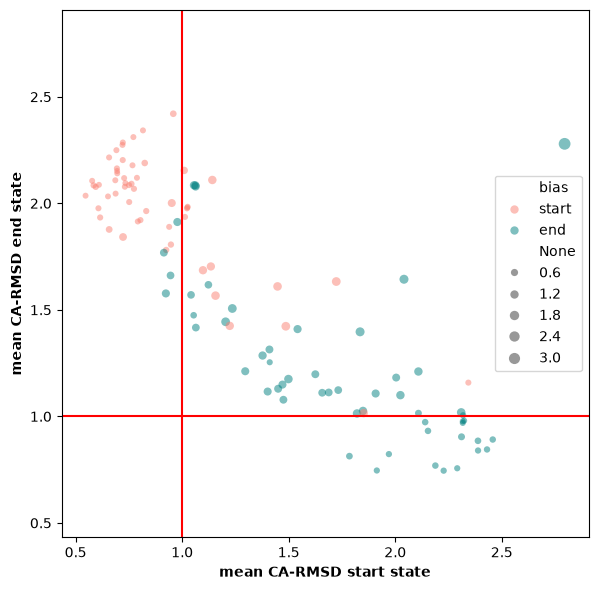

In [32]:
# plot
fig, ax = plt.subplots(figsize=(8, 6))

# aggregate
scores_agg = scores.groupby('name').agg(
    start_rmsd_mean=('start_rmsd', 'mean'),
    start_rmsd_std=('start_rmsd', 'std'),
    end_rmsd_mean=('end_rmsd', 'mean'),
    end_rmsd_std=('end_rmsd', 'std'),
    bias=('bias', 'first')
).reset_index()

# start biased
graph_df = scores_agg
start_sc = sns.scatterplot(
    x = graph_df['start_rmsd_mean'],
    y = graph_df['end_rmsd_mean'],
    hue = graph_df['bias'],
    size = (graph_df['start_rmsd_std'] + graph_df['end_rmsd_std']),
    palette = {
        'start': 'salmon',
        'end': 'teal'
    },
    linewidth = 0,
    ax = ax,
    alpha = 0.5,
    legend = True
)

# cutoff
ax.axhline(
    y=1,
    color='red'
)
ax.axvline(
    x=1,
    color='red'
)

# axes
ax.set_xlabel(
    'mean CA-RMSD start state',
    fontweight='bold'
)
ax.set_ylabel(
    'mean CA-RMSD end state',
    fontweight='bold'
)
axmin = min(
    ax.get_xlim()[0],
    ax.get_ylim()[0]
)
axmax = max(
    ax.get_xlim()[1],
    ax.get_ylim()[1]
)
ax.set_xlim(axmin, axmax)
ax.set_ylim(axmin, axmax)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
# return opposite
flip_state = {
    'start': 'end',
    'end': 'start'
}
eps = 0.5

# filter
keep = np.zeros(len(scores), dtype=bool)

# group by name
for name in np.unique(scores['name']):

    # get rows
    rows = scores[scores['name'] == name]
    assert len(rows) == 5

    # check rmsd bias
    bias = rows[f'{rows.iloc[0]['bias']}_rmsd']
    if not (bias < 1).all():
        keep[
            list(rows.index)
        ] = False
    else:

        # check other
        other = rows[f'{flip_state[rows.iloc[0]['bias']]}_rmsd']
        if not (other.mean() > (2 + bias.mean() - eps)):
            keep[
                list(rows.index)
            ] = False
        else:
            keep[
                list(rows.index)
            ] = True


60


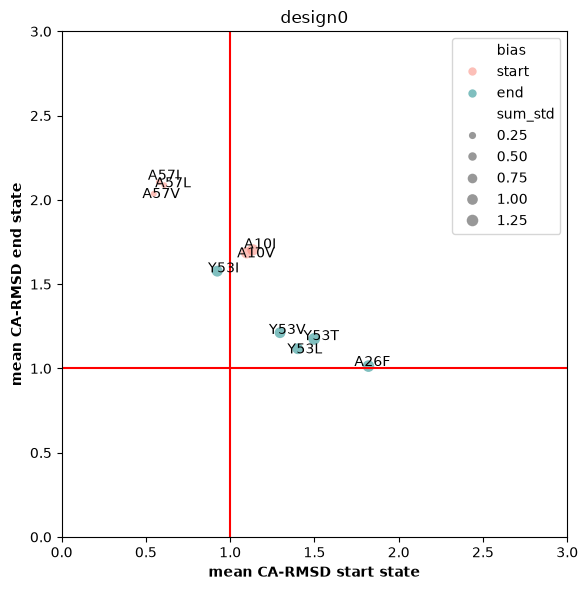

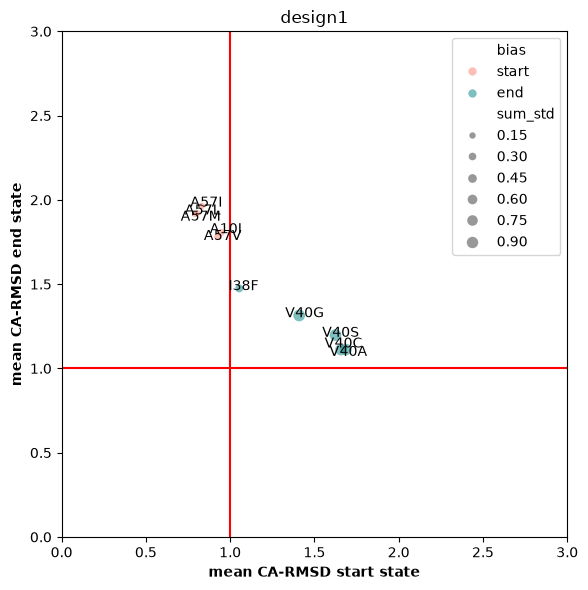

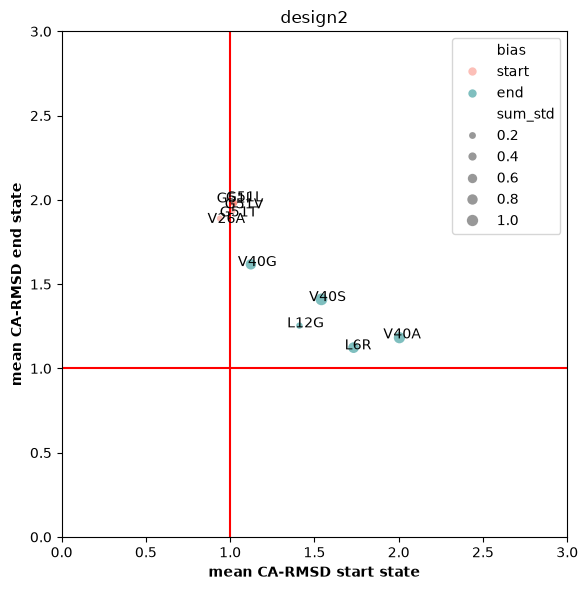

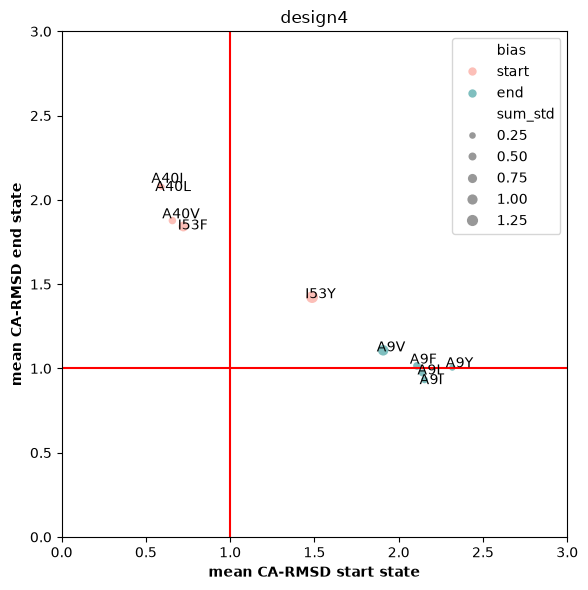

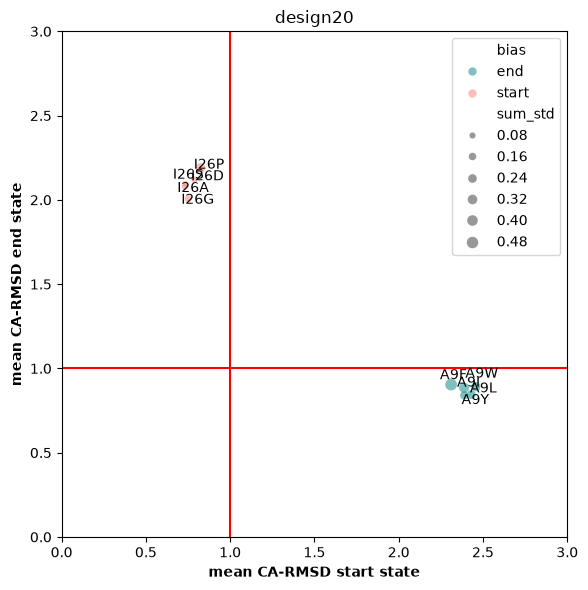

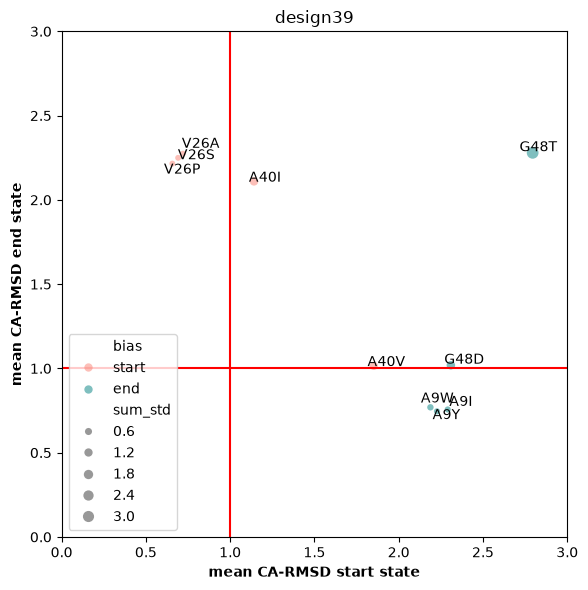

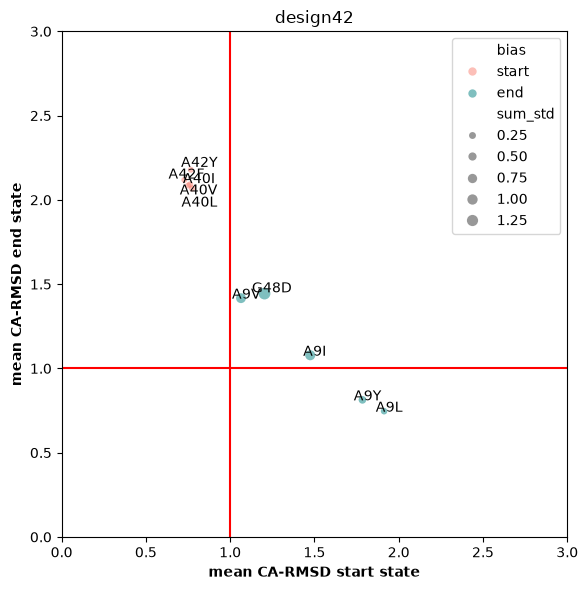

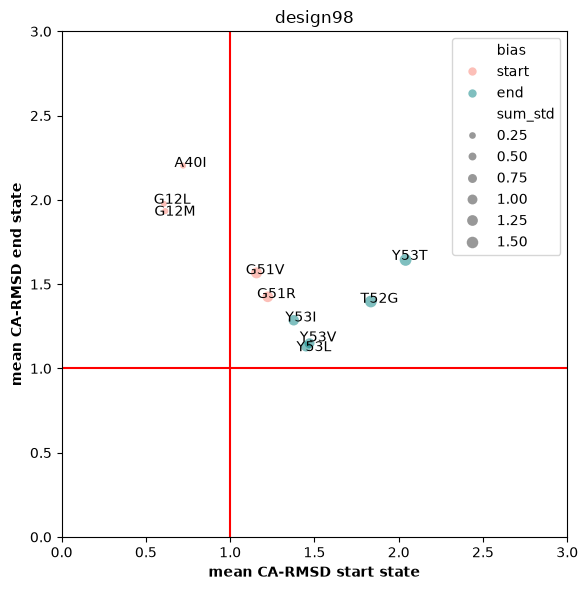

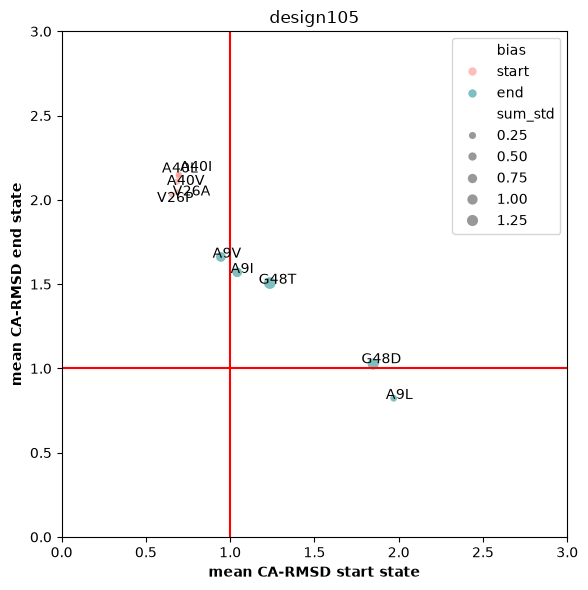

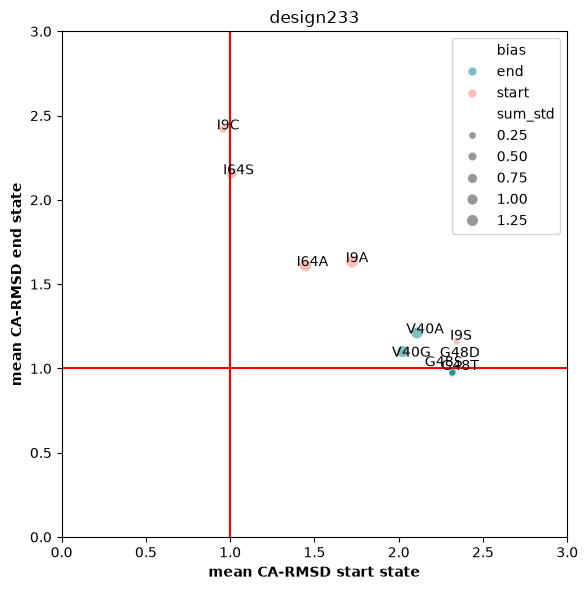

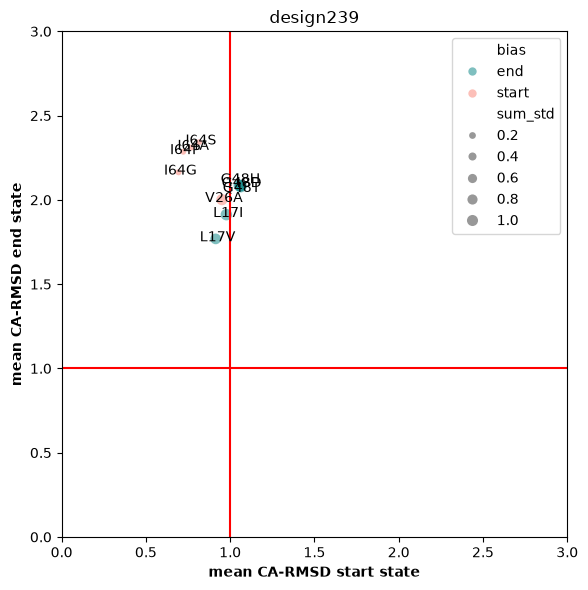

In [50]:
for design_num in np.unique(scores['design']):

    # all mutants for single design
    design_scores = scores_agg[scores_agg['name'].str.contains(f'design-{design_num}_')]

    # plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # start biased
    graph_df = design_scores
    graph_df['sum_std'] = graph_df['start_rmsd_std'] + graph_df['end_rmsd_std']
    start_sc = sns.scatterplot(
        x = graph_df['start_rmsd_mean'],
        y = graph_df['end_rmsd_mean'],
        hue = graph_df['bias'],
        size = graph_df['sum_std'],
        palette = {
            'start': 'salmon',
            'end': 'teal'
        },
        linewidth = 0,
        ax = ax,
        alpha = 0.5,
        legend = True
    )

    # names
    labels = [
        ax.text(
            row['start_rmsd_mean'],
            row['end_rmsd_mean'],
            row['name'].split('_mut-')[1].split('_bias-')[0]
        )
        for _, row in graph_df.iterrows()
    ]
    adjust_text(labels)

    # for _, row in graph_df.iterrows():
    #     ax.annotate(
    #         , #type: ignore
    #         (, r),
    #         xytext=(1, 1),
    #         textcoords='offset points'
    #     )

    # cutoff
    ax.axhline(
        y=1,
        color='red'
    )
    ax.axvline(
        x=1,
        color='red'
    )

    # axes
    ax.set_xlabel(
        'mean CA-RMSD start state',
        fontweight='bold'
    )
    ax.set_ylabel(
        'mean CA-RMSD end state',
        fontweight='bold'
    )
    axmin = min(
        ax.get_xlim()[0],
        ax.get_ylim()[0]
    )
    axmax = max(
        ax.get_xlim()[1],
        ax.get_ylim()[1]
    )
    #ax.set_xlim(axmin, axmax)
    #ax.set_ylim(axmin, axmax)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    ax.set_title(f'design{design_num}')
    plt.tight_layout()
    plt.show()


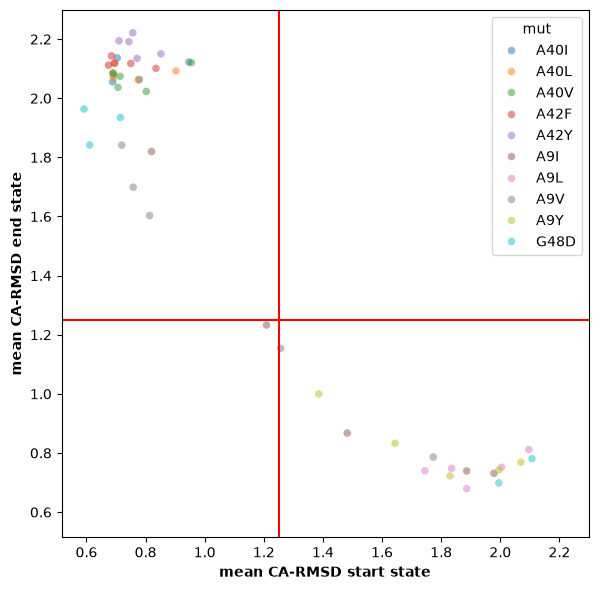

In [56]:
# best mutants for single design, plot all predictions
design_num = 42
design_scores = scores_agg[scores_agg['name'].str.contains(f'design-{design_num}_')]

# mutants = [
# ]

scores['mut'] = scores['name'].apply(
    lambda name: name.split('_mut-')[1].split('_bias-')[0]
)
graph_df = scores[
    (scores['design'] == design_num)
    # & scores['mut'].isin(mutants)
]

#-----
# plot
fig, ax = plt.subplots(figsize=(8, 6))

# start biased
start_sc = sns.scatterplot(
    x = graph_df['start_rmsd'],
    y = graph_df['end_rmsd'],
    hue = graph_df['mut'],
    s = 30,
    palette = 'tab10',
    linewidth = 0,
    ax = ax,
    alpha = 0.5,
    legend = True
)

# cutoff
ax.axhline(
    y=1.25,
    color='red'
)
ax.axvline(
    x=1.25,
    color='red'
)

# axes
ax.set_xlabel(
    'mean CA-RMSD start state',
    fontweight='bold'
)
ax.set_ylabel(
    'mean CA-RMSD end state',
    fontweight='bold'
)
axmin = min(
    ax.get_xlim()[0],
    ax.get_ylim()[0]
)
axmax = max(
    ax.get_xlim()[1],
    ax.get_ylim()[1]
)
ax.set_xlim(axmin, axmax)
ax.set_ylim(axmin, axmax)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


#### Misc

In [34]:
df = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/notebooks/data/data/5KPE-5KPH_refined_multi-state3_temp2_data.csv'
)
df = df[
    df['name'].str.contains('5KPH_2_2_7_0_combined_id9')
]

In [35]:
print(df['plddt'].max())
print(df['plddt'].mean())

92.36652777777778
91.24176851851851


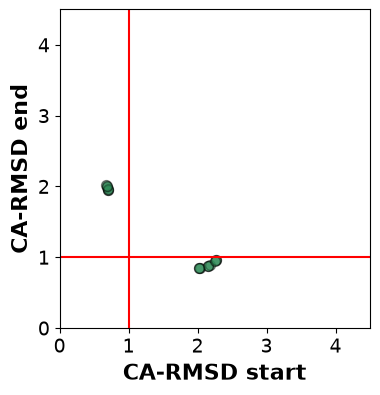

0.6709741950035095
0.8417376279830933


In [36]:
plt.figure(figsize=(4, 4))
plt.scatter(
    df['rmsd_start'],
    df['rmsd_end'],
    c = 'seagreen',
    s = 50,
    alpha = 0.5,
    edgecolor='black'
)
plt.axvline(
    x=1,
    color='red'
)
plt.axhline(
    y=1,
    color='red'
)
plt.xlabel('CA-RMSD start', fontweight='bold', fontsize=16)
plt.ylabel('CA-RMSD end', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.xlim(0, 4.5)
plt.ylim(0, 4.5)
plt.tick_params(
    labelsize=14
)
plt.show()

print(df['rmsd_start'].min())
print(df['rmsd_end'].min())

In [43]:
scores_agg[
    scores_agg['name'].str.contains('design-42')
]

,name,start_rmsd_mean,start_rmsd_std,end_rmsd_mean,end_rmsd_std,bias
80,design-42_mut-A40I_bias-start,0.762042,0.109475,2.091576,0.036180,start
81,design-42_mut-A40L_bias-start,0.750640,0.092291,2.085456,0.021913,start
82,design-42_mut-A40V_bias-start,0.773724,0.110396,2.068102,0.039030,start
83,design-42_mut-A42F_bias-start,0.727682,0.066768,2.118471,0.015607,start
84,design-42_mut-A42Y_bias-start,0.766837,0.052676,2.178342,0.035238,start
85,design-42_mut-A9I_bias-end,1.475130,0.480156,1.078095,0.462001,end
86,design-42_mut-A9L_bias-end,1.913504,0.138747,0.746099,0.046833,end
87,design-42_mut-A9V_bias-end,1.064260,0.451369,1.416794,0.436346,end
88,design-42_mut-A9Y_bias-end,1.784924,0.276683,0.813392,0.112164,end
89,design-42_mut-G48D_bias-end,1.203825,0.775727,1.444040,0.645089,end
